# Immunoglobulin ML — Model Training

**Author:** Jesse Gunn Cheu 
**Date:** 2026-04-01  
**Description:** This project utilizes machine learning techniques in order to conduct an analysis on immunglobulin gene annotations. These annotations are output from the program DIGGER and were manuall;y curated by Ashley Reers at Tulane University.

**Acknowledgements:** This project served as a cummulating project for an applied machine learning course taught by Dr. Brian King. This work has been conducted during my time as a researcher in the Field Lab at bucknell University and our datasets come from our *Epomorphous labiatus* bat genome. Lastly, generative AI including ChatGPT, Claude AI, and vscode's copilot was used in constructing this notebook. The code has all been reviewed and editing by myself however and I have taken my time to review my usage of AI throughout my work here.

## Dependencies
 - Python 3.13.11

### Standard Library
- `__future__`
- `itertools`
- `time`

### Core
- `numpy`
- `pandas`

### Visualization
- `matplotlib`
- `seaborn`

### Scientific / Stats
- `scipy`
- `sklearn` (scikit-learn)

### Local Modules
- `kmer_polished`

In [2]:
# Import Packages
# Basics
from __future__ import annotations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import importlib

# Stats & Viz
from itertools import combinations # Suggested by ChatGPT
from scipy.stats import zscore
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import pairwise_distances
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, f1_score, log_loss
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay

# Train/Test Split & CV
from sklearn.model_selection import train_test_split, KFold
from sklearn.utils import shuffle
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.model_selection import GridSearchCV

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# MINE
import kmer_polished
importlib.reload(kmer_polished)

<module 'kmer_polished' from 'w:\\Projects\\ImmunoglobulinML\\kmer_polished.py'>

# Loading in data
As you may be able to notice, the data is not open source in this repository as our data has not yet been published for public use. It can be made upon request to jjgc001@bucknell.edu and/or kfield@bucknell.edu

What is important to know is that our data comes from two gff files. One is the direct output from digger which will be refered to as *raw* and the other is a manually curated gff file which will be refered to as *cur*. 

In [5]:
# Loading data or making dataframes from gff files if csv files not found
try :
    raw_df = pd.read_csv('igl_raw_2_ 3_ 6_kmers.csv')
except FileNotFoundError:
    print("File not found for raw_df, making raw_df from gff")
    raw_df = kmer_polished.beautify_gff("HLepoLabi.1.2.h1.cur.20251110.2bit", "Data/epolab_hap1_digger_igl_annotations_raw.gff", "raw")

try :
    cur_df = pd.read_csv('igl_cur_2_ 3_ 6_kmers.csv')
except FileNotFoundError:
    print("File not found for cur_df, making cur_df from gff")
    cur_df = kmer_polished.beautify_gff("HLepoLabi.1.2.h1.cur.20251110.2bit", "Data/epolab_hap1_digger_annotations_igl_polished.gff", "cur")

# Create a merged dataframe and extract gene_type and gene_function from the 'feature' column using regex
full_df = pd.concat([raw_df, cur_df], ignore_index=True)
full_df[['gene_type', 'gene_function']] = full_df['feature'].str.extract(r'(\S+)\s+\(([^)]+)\)')

C:\Users\jesse\AppData\Local\Temp\ipykernel_41324\3436385979.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_df[['gene_type', 'gene_function']] = full_df['feature'].str.extract(r'(\S+)\s+\(([^)]+)\)')


# Exploratory Data Analysis
Before begining the machine learning process, I wanted to take a brief look to see what gene types might hold the most information / be the most useful to conduct this process on. I am specifically looking for gene types that have a larger number in the raw file than the curated file. This would signal to us that there were genes filtered out during the manual curation process that we could then use for our analysis.

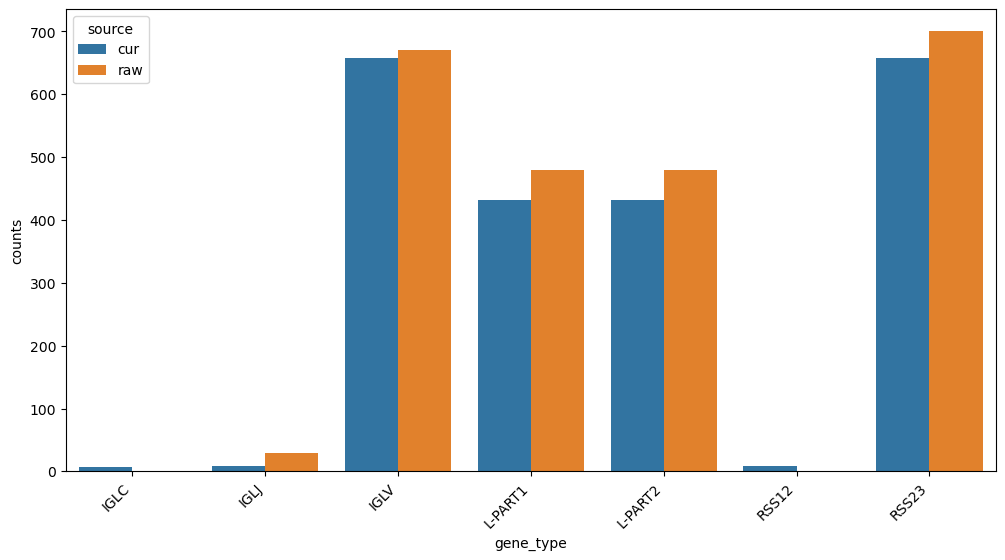

In [6]:
# Take a look at the distribution of features in the raw and polished datasets
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=full_df.groupby(['source', 'gene_type']).size().reset_index(name='counts'),
    x='gene_type',
    y='counts',
    hue='source'
)
# Rotate x-axis labels for better readability and move to the right
plt.xticks(rotation=45, ha='right')

#save graph
plt.savefig('viz/feature_counts_by_source.png', bbox_inches='tight')
plt.show()

Like I said before, we want to look at genes with the greatest difference between the curated and raw files but importantly with the raw file having more genes than the curated file.

In [158]:
# Get differences in feature counts between raw and polished datasets
feature_counts = full_df.groupby(['source', 'gene_type']).size().reset_index(name='counts').pivot(index='gene_type', columns='source', values='counts').fillna(0)
feature_counts['difference'] = feature_counts['cur'] - feature_counts['raw']
feature_counts = feature_counts.sort_values(by='difference', ascending=True)
print(feature_counts[['raw', 'cur', 'difference']])

source       raw    cur  difference
gene_type                          
L-PART1    479.0  432.0       -47.0
L-PART2    479.0  432.0       -47.0
RSS23      700.0  658.0       -42.0
IGLJ        29.0    9.0       -20.0
IGLV       671.0  658.0       -13.0
IGLC         0.0    7.0         7.0
RSS12        0.0    9.0         9.0


HERE I WILL EXPLAIN WHY I CHOSE IGLJ

# Preprocessing

Although we did some data cleaning in the first step with reading in the files, we are now going to choose a specific gene type to analyze and further reduce our dataset using this feature.

In [7]:
# This is the gene type the analysis will be conducted on
selected_feature = "RSS23"

In [29]:
%%time
filter_full = full_df[full_df['gene_type'] == selected_feature].copy()

# Find kmer columns
mer_cols = [col for col in filter_full.columns if "mer" in col]

# Drop single-value kmer columns in one operation
cols_to_drop = [col for col in mer_cols if filter_full[col].nunique() == 1]
filter_full.drop(columns=cols_to_drop, inplace=True)

# Downcast remaining kmer columns in one operation
mer_cols_remaining = [col for col in mer_cols if col not in cols_to_drop]
filter_full[mer_cols_remaining] = filter_full[mer_cols_remaining].apply(pd.to_numeric, downcast="float")

# Categorical and index
filter_full['source'] = filter_full['source'].astype('category')
filter_full["seq_ID"] = [f"seq_{i}" for i in range(len(filter_full))]
filter_full = filter_full.set_index('seq_ID')

CPU times: total: 1.67 s
Wall time: 1.77 s


<timed exec>:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`


# Remove similar sequences

As I mentioned before, there are genes in the raw file that are going to be similar to genes in the curated file because they are the same or only slightly altered and kept. This step is to make sure that any kept genes are denoted in the curated file and not the raw file. This is to ensure our classifier will have two distinct classes of "correct" or "incorrect" gene annotations and anything that is kept will be considered correct.

In [30]:
# Reformat to only numeric columns for pdist
num_df = filter_full.select_dtypes(include=[np.number])
num_df = num_df.drop(columns=['length']) # Drop non-informative columns
num_df_rounded = num_df.round(10) # Round to 10 decimal places to reduce memory usage and prevent floating point precision issues

In [31]:
# Create distance matrix
pdist_matrix = pairwise_distances(num_df_rounded, metric='euclidean')
pdist_matrix[pdist_matrix < 1e-10] = 0.0 # Set very small distances to zero to avoid floating point issues
distmat = pd.DataFrame(pdist_matrix, index=num_df_rounded.index, columns=num_df_rounded.index) # Automatic help from CoPilot
print(distmat.shape)
distmat.head(3)

(1358, 1358)


seq_ID,seq_0,seq_1,seq_2,seq_3,seq_4,seq_5,seq_6,seq_7,seq_8,seq_9,...,seq_1348,seq_1349,seq_1350,seq_1351,seq_1352,seq_1353,seq_1354,seq_1355,seq_1356,seq_1357
seq_ID,,,,,,,,,,,,,,,,,,,,,
seq_0,0.000000e+00,8.010346e+05,2.253580e+06,5.278677e+06,7.811822e+06,8.274323e+06,1.495563e+07,1.498184e+07,1.499003e+07,1.500457e+07,...,1.797604e+07,1.796862e+07,1.796100e+07,1.795362e+07,1.794805e+07,1.794171e+07,1.793772e+07,1.793138e+07,1.792392e+07,1.791570e+07
seq_1,8.010346e+05,0.000000e+00,1.452546e+06,4.477642e+06,7.010788e+06,7.473289e+06,1.415460e+07,1.418081e+07,1.418900e+07,1.420354e+07,...,1.717501e+07,1.716758e+07,1.715997e+07,1.715259e+07,1.714701e+07,1.714068e+07,1.713669e+07,1.713034e+07,1.712289e+07,1.711466e+07
seq_2,2.253580e+06,1.452546e+06,0.000000e+00,3.025096e+06,5.558242e+06,6.020743e+06,1.270205e+07,1.272826e+07,1.273645e+07,1.275099e+07,...,1.572246e+07,1.571504e+07,1.570742e+07,1.570004e+07,1.569447e+07,1.568813e+07,1.568414e+07,1.567780e+07,1.567034e+07,1.566212e+07


In [32]:
# Reformat the output so we can see all the sequence pairs and distances
tmp = distmat.copy()
tmp.index.name = "row_id"
tmp.columns.name = "col_id"

pairs_df = (
    tmp.stack()
       .reset_index()
       .rename(columns={"row_id": "seq_first", "col_id": "seq_second", 0: "distance"})
)

pairs_df = pairs_df[pairs_df["seq_first"] < pairs_df["seq_second"]] # Keep only one of the two pairs (seq1, seq2) and (seq2, seq1) since they are the same distance
print(pairs_df.shape)
pairs_df.head(3)

(921403, 3)


,seq_first,seq_second,distance
1,seq_0,seq_1,8.010346e+05
2,seq_0,seq_2,2.253580e+06
3,seq_0,seq_3,5.278677e+06


<Axes: xlabel='distance', ylabel='Count'>

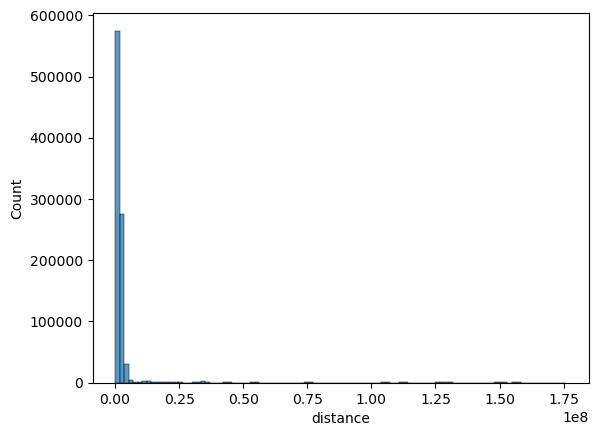

In [33]:
sns.histplot(pairs_df["distance"], bins=100)

I am looking at this plot in order to see if there is a cutoff point other than 0 that might show if two sequences are similar enough to call the same. For now I am going to use a distance of 0.1 because anything higher removed too many sequences to identify the same sequences.

In [34]:
# Identify duplicates based on a distance threshold

pairs_dup = pairs_df[pairs_df["distance"] == 0]
seq_ids = set(pairs_dup["seq_first"]).union(set(pairs_dup["seq_second"]))
seq_ids_list = list(seq_ids)
seq_ids_list[:5] # This is what we are going to use to remove duplicates

['seq_1095', 'seq_243', 'seq_266', 'seq_552', 'seq_675']

In [35]:
# Filter out duplicates from Digger sequences only

before_count = filter_full.shape[0]
filter_full_cur = filter_full[filter_full["source"] == "cur"]
before_count_cur = filter_full_cur.shape[0]
filter_full_raw = filter_full[filter_full["source"] == "raw"]
before_count_raw = filter_full_raw.shape[0]
filter_full_raw = filter_full_raw[~filter_full_raw.index.isin(seq_ids_list)]
filter_final = pd.concat([filter_full_cur, filter_full_raw])
after_count = filter_final.shape[0]
print(f"Before count: {before_count}, After count: {after_count}")
print(f"curated count before: {before_count_cur}, digger count before: {before_count_raw}")
print(f"curated count: {filter_full_cur.shape[0]}, digger count: {filter_full_raw.shape[0]}")

Before count: 1358, After count: 700
curated count before: 658, digger count before: 700
curated count: 658, digger count: 42


Here we were able to succesfully create the dataframe we will need for our analysis and classifier. Hopefully we will not be seeing a great deal of overlap between the digger and curated annotations because we did this filtering.

# Exploratory Data Analysis 2

For the second part of my EDA I am going to first check distribution to see if it is more even now that I have removed the duplicates. I am then goign to look at some PCA plots to see if there are any clear divisions between my two classes. I will also then see if any specific features are highly different between the classes in their counts which will serve as an indicator for kmers that might serve as important markers for distinguishing correct and incorrect annotations.

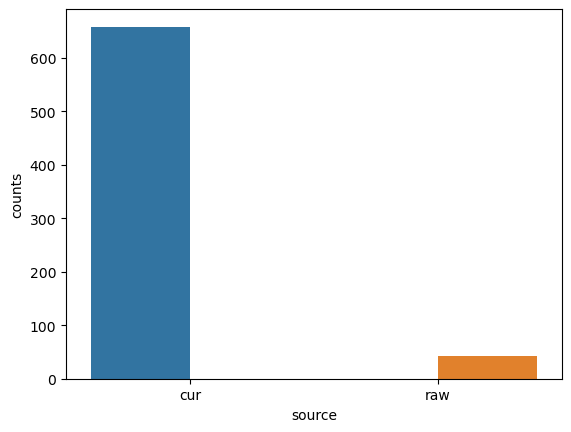

In [36]:
# Visualize final counts to see ditribution between classes

filter_viz = filter_final.groupby('source').size().reset_index(name = 'counts');
sns.barplot(data=filter_viz, x='source', y='counts', hue ='source');

In [79]:
# Perform PCA
pca_df = pd.concat([filter_final.loc[:, filter_final.columns.str.contains("mer")]], axis=1)
zscore_df = pca_df.apply(zscore)

pca = PCA(pca_df.shape[0])
pca_df = pd.DataFrame(pca.fit_transform(zscore_df))

# Generated by ChatGPT
summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(pca.n_components_)],
    "Explained Variance": pca.explained_variance_,
    "Explained Variance Ratio": pca.explained_variance_ratio_,
})

print(summary.head(5))

    PC  Explained Variance  Explained Variance Ratio
0  PC1           38.004036                  0.023988
1  PC2           33.512508                  0.021153
2  PC3           31.909773                  0.020142
3  PC4           29.314247                  0.018503
4  PC5           28.611328                  0.018060


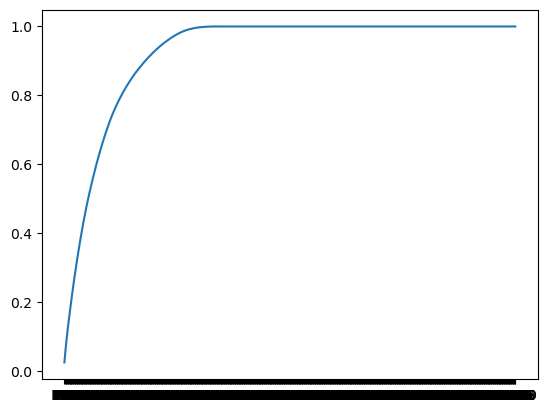

In [80]:
# Help from ChatGPT
cum_var = np.cumsum(pca.explained_variance_ratio_)
plt.plot([f"PC{i}" for i in range(1, pca_df.shape[0] + 1)], cum_var)

It does not seem like we can reliably compress our data into a small number of dimensions.

In [81]:
pca_plot_df = pd.concat([pca_df.iloc[:, 0:3], filter_final['source'].reset_index(drop=True)], axis=1)
pca_plot_df.columns = ['PC1', 'PC2', 'PC3', 'source']

Text(0.5, 0, 'PC3')

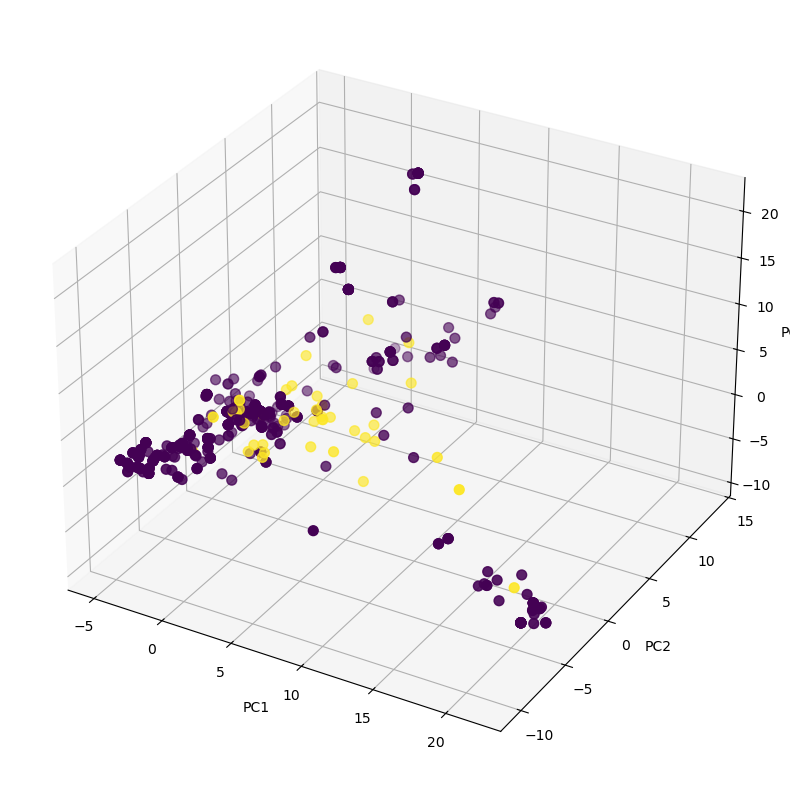

In [82]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(pca_plot_df.iloc[:,0], pca_plot_df.iloc[:,1], pca_plot_df.iloc[:,2], c=pca_plot_df['source'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")


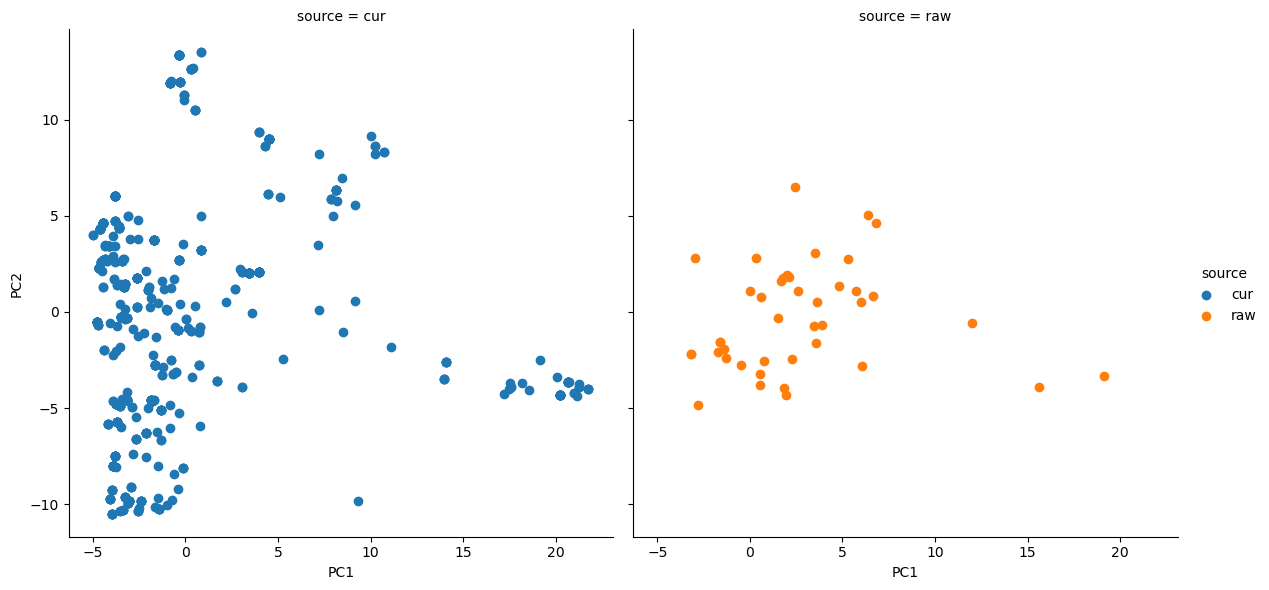

In [83]:
# This is to see if there was overlap that can be difficult to see if there was a lot of overlap
g = sns.FacetGrid(pca_plot_df, col = 'source', hue="source", height=6)
g.map(plt.scatter, "PC1", "PC2").add_legend()

<Axes: xlabel='PC1', ylabel='PC2'>

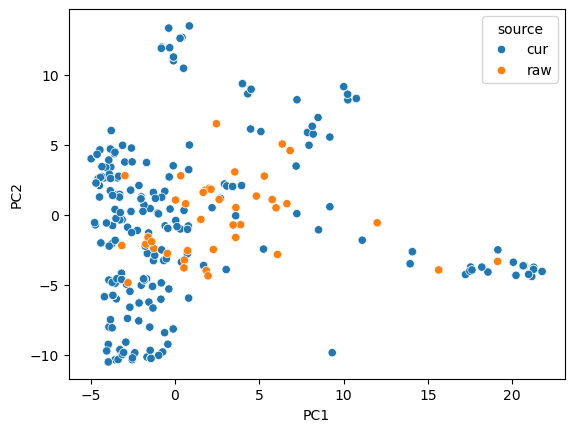

In [84]:
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='source')

In originally analyzing the IGLH, there was ALOT of overlap becuase there were minimal edits between the digger and curate annotations. As we can see here with IGLJ however there is not much overlap and we can see that there is a distinction between the two classes that should allow us to create a classifier.

In [85]:
# Dataframe to look at kmer means by class

split_df = filter_final.loc[:, filter_final.columns.str.contains("mer") | (filter_final.columns == 'source')];
split_df = split_df.melt(id_vars=list(split_df.columns[~split_df.columns.str.contains("mer")]));
split_df = split_df.groupby(['variable', 'source']).mean().sort_values(by=['variable', 'source']);
split_df_target = split_df.reset_index().pivot(index='variable', columns='source', values='value');
split_df_target["Difference"] = split_df_target["cur"] - split_df_target["raw"];
split_df_target = split_df_target.sort_values(by="Difference", ascending=False);
print(split_df.head(3));
print(split_df_target.head(3));

                    value
variable source          
2mer_AA  cur     0.102062
         raw     0.074619
2mer_AC  cur     0.103268
source         cur       raw  Difference
variable                                
2mer_GA   0.107952  0.054670    0.053282
2mer_GG   0.078141  0.043212    0.034929
2mer_AG   0.102738  0.068243    0.034495


C:\Users\jesse\AppData\Local\Temp\ipykernel_41324\814667542.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right");


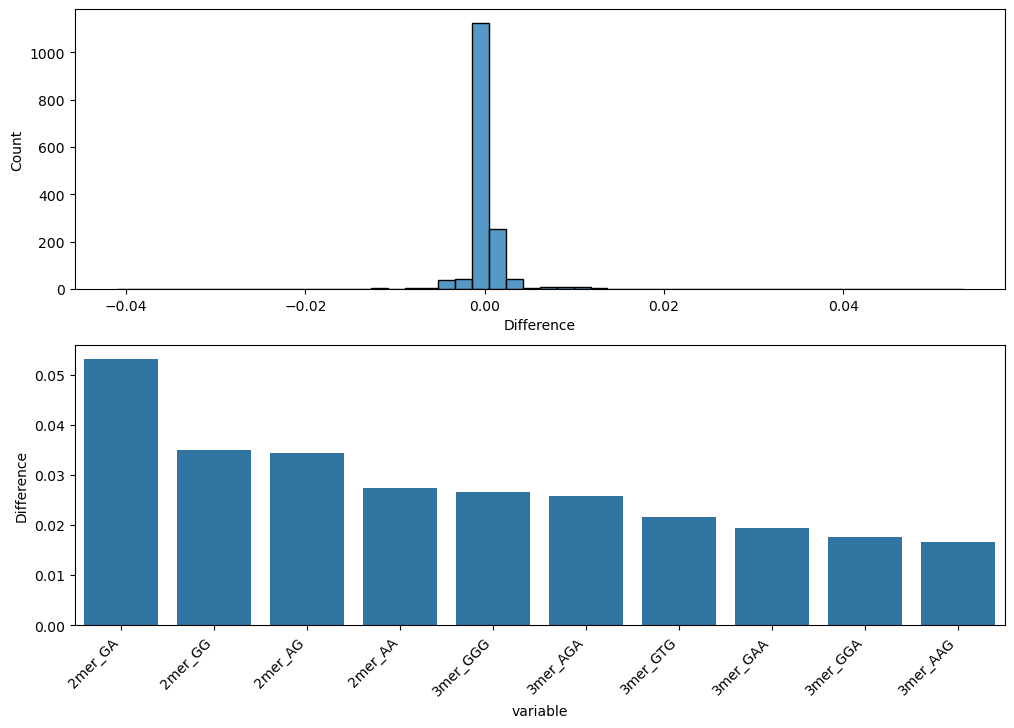

In [86]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8));

sns.histplot(split_df_target["Difference"], bins=50, ax=ax[0]);

sns.barplot(split_df_target.head(10).reset_index(), x = "variable", y="Difference", ax=ax[1]);
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right");

Firstly that there is not a huge difference between the two classes overall as we can see from the histogram being fairly close to 0. We can also see from the second graph which sequences seem to be the most different between the two classes which might be a clue as to which features might be important for determining if an annotations is correct or incorrect.

# Classifier
For now I am going to just make a simple decision tree then move into using logistic regression. A decision tree will be interesting for this data becuase it can show what features / kmers can be important for splitting the data. I will then use logistic regression because it will be better at handling the data because of the high number of features it has and I think it will create a stronger model using weights.

In [56]:
# Create X and Y for ML

X_2 = filter_final.loc[:, filter_final.columns.str.contains("2mer")] # Create a training set for 2mers
X_3 = filter_final.loc[:, filter_final.columns.str.contains("3mer")] # Create a training set for 3mers
X_6 = filter_final.loc[:, filter_final.columns.str.contains("6mer")] # Create a training set for 6mers
X_ALL = filter_final.loc[:, filter_final.columns.str.contains("mer")]

#X = pd.concat([X, filter_final['length']], axis=1) # I decided not to include length for now as I want to focus on if this problem can be solved using Kmers
Y = filter_final['source'].cat.codes

In [49]:
def decision_tree_analysis(X, Y, title):
    clf = DecisionTreeClassifier(random_state=0) # Basic Decision Tree Classifier

    pred_dt = cross_val_predict(clf, X, Y, cv=5) # Initial Test
    print(classification_report(Y, pred_dt)) # Show classification report

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    cfm = confusion_matrix(Y, pred_dt)
    ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
    ax[0].set_title(title)

    clf.fit(X_2, Y)
    ax[1] = tree.plot_tree(
        clf,
        class_names=[str(c) for c in clf.classes_],
        feature_names=[str(f) for f in X.columns],
        filled=True
    );

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       658
           1       0.76      0.62      0.68        42

    accuracy                           0.97       700
   macro avg       0.87      0.80      0.83       700
weighted avg       0.96      0.97      0.96       700



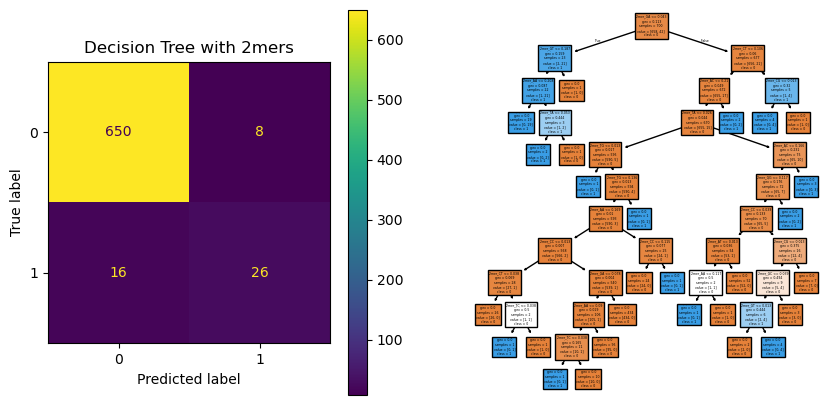

In [50]:
decision_tree_analysis(X_2, Y, "Decision Tree with 2mers")

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       658
           1       0.74      0.60      0.66        42

    accuracy                           0.96       700
   macro avg       0.85      0.79      0.82       700
weighted avg       0.96      0.96      0.96       700



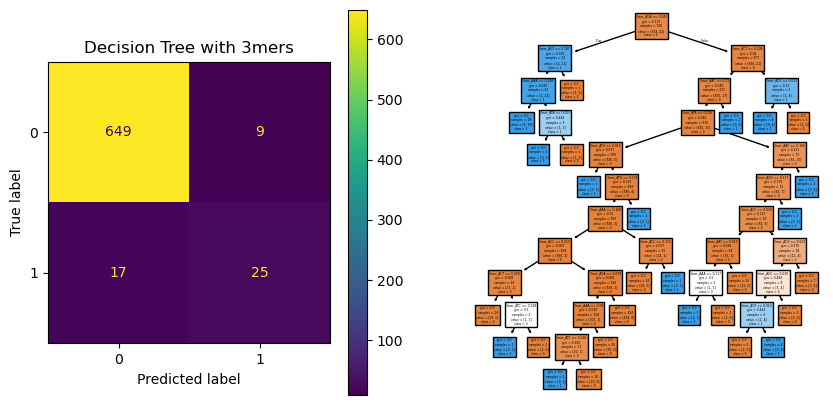

In [51]:
decision_tree_analysis(X_3, Y, "Decision Tree with 3mers")

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       658
           1       0.76      0.31      0.44        42

    accuracy                           0.95       700
   macro avg       0.86      0.65      0.71       700
weighted avg       0.95      0.95      0.94       700



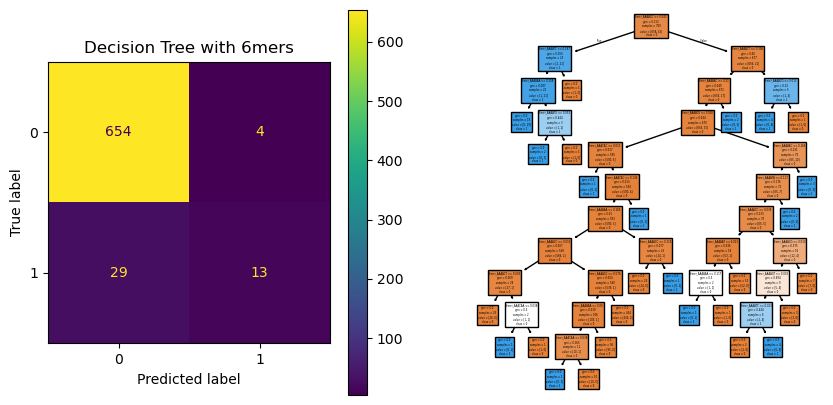

In [52]:
decision_tree_analysis(X_6, Y, "Decision Tree with 6mers")

When I originally conducted this IGLH, I yielded very poor results where my classifier actually performed worse than simple random guessing. Again this is becuase of the huge overlap between the two classes. With IGLJ however we can see that there is a high degree of accuracy because the classes can actually be differentiated. An important part of this tool however is going to be to minimize the False negatives. We only want to remove the annotations that we are certain are inccorect with high confidence. Ideally we want to only check over the annotations we are confident are in the final dataset and minimize how many annotations we must manually look over. Because of this we want to maximize our precision metric.

In [53]:
def grid_search_decision_tree(X, name, Y):
    print(f"Running Grid Search for Decision Tree with {X.columns[0].split('mer')[0]}mers...")
    start_time = time.time()
    param_grid = { 'criterion' : ['gini', 'entropy'],
               'max_depth' : [4,5,6,7,8,9],
               'min_samples_split' : [3,4,5,6],
               'min_samples_leaf' : [1,2,3,4,5]
             }

    grid = GridSearchCV(DecisionTreeClassifier(), param_grid, scoring = ["precision"],
                    refit="precision", n_jobs=-1,
                    return_train_score=True, cv=10)

    grid_result = grid.fit(X,Y)
    end_time = time.time()
    print(f"Best score for decision tree with {name}: {grid_result.best_score_}")
    print(f"Best params for decision tree with {name}: {grid_result.best_params_}")
    print(f"Time taken for decision tree with {name}: {end_time - start_time:.2f} seconds")    

    return grid_result.best_score_, grid_result.best_params_

In [54]:
def iterate_decision_tree(X_list, names, Y):
    best_df = []
    best_score = 0
    best_params = []
    best_name = ""
    for X, name in zip(X_list, names):
        score, params = grid_search_decision_tree(X, name, Y)
        if score > best_score:
            best_df = X
            best_score = score
            best_params = params
            best_name = name
    print(f"Best overall score: {best_score} with {best_name} and params: {best_params['criterion']}, {best_params['max_depth']}, {best_params['min_samples_split']}, {best_params['min_samples_leaf']}")
    return best_df, best_score, best_params, best_name

In [57]:
dt_best_df, dt_best_score, dt_best_params, dt_best_name = iterate_decision_tree([X_2, X_3, X_6, X_ALL], ["2mer", "3mer", "6mer"], Y)

Running Grid Search for Decision Tree with 2mers...
Best score for decision tree with 2mer: 0.9416666666666667
Best params for decision tree with 2mer: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 5}
Time taken for decision tree with 2mer: 13.45 seconds
Running Grid Search for Decision Tree with 3mers...
Best score for decision tree with 3mer: 0.9433333333333334
Best params for decision tree with 3mer: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 3}
Time taken for decision tree with 3mer: 6.99 seconds
Running Grid Search for Decision Tree with 6mers...
Best score for decision tree with 6mer: 0.8266666666666665
Best params for decision tree with 6mer: {'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 4, 'min_samples_split': 4}
Time taken for decision tree with 6mer: 175.19 seconds
Best overall score: 0.9433333333333334 with 3mer and params: entropy, 8, 3, 1


              precision    recall  f1-score   support

           0       0.78      0.95      0.86       658
           1       0.43      0.13      0.20       200

    accuracy                           0.76       858
   macro avg       0.61      0.54      0.53       858
weighted avg       0.70      0.76      0.70       858



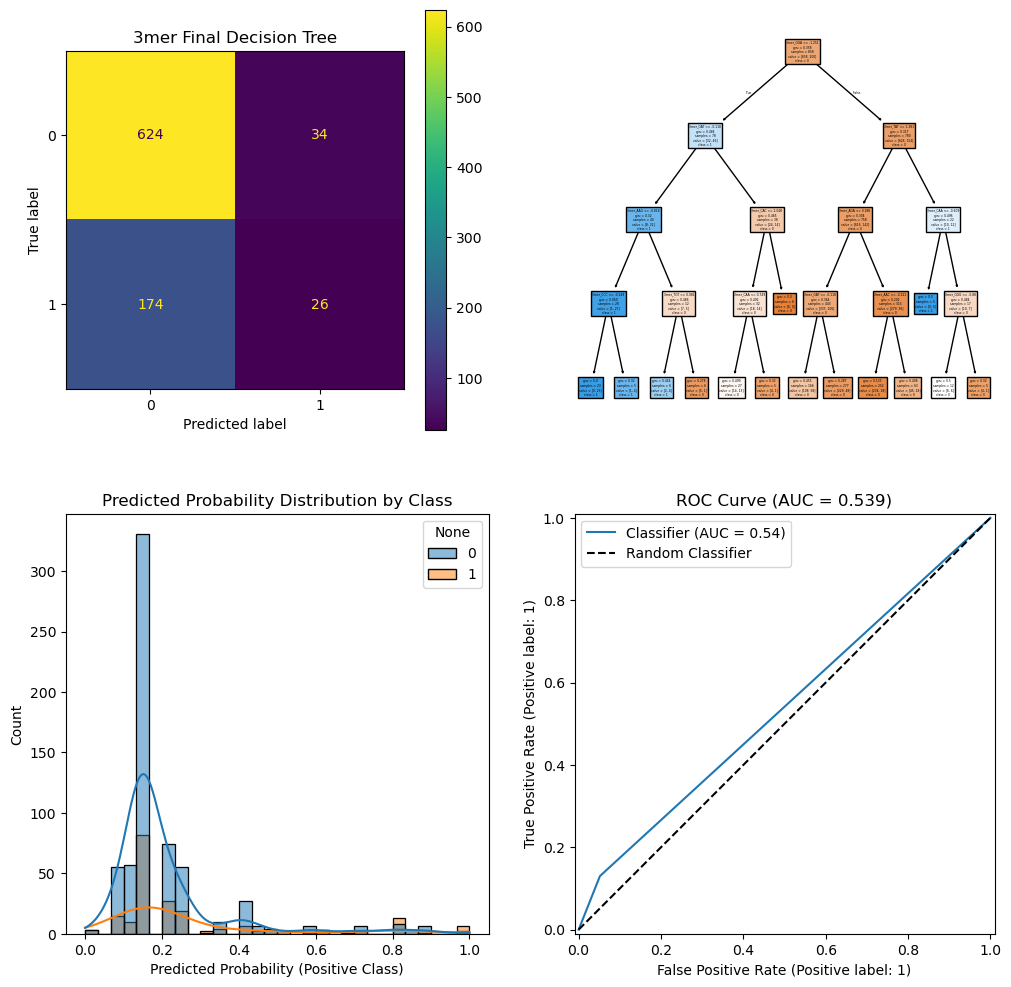

In [351]:
dt_final = DecisionTreeClassifier(criterion=dt_best_params['criterion'], max_depth=dt_best_params['max_depth'], min_samples_split=dt_best_params['min_samples_split'], min_samples_leaf=dt_best_params['min_samples_leaf']) # Decision Tree Classifier based on best params

pred_dt_final = cross_val_predict(dt_final, dt_best_df, Y, cv=5) # Initial Test
print(classification_report(Y, pred_dt_final)) # Show classification report
fig, ax = plt.subplots(2, 2, figsize=(12,12));

cfm = confusion_matrix(Y, pred_dt_final)
ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0, 0])
ax[0, 0].set_title(f"{dt_best_name} Final Decision Tree")

dt_final.fit(dt_best_df, Y)
tree.plot_tree(
    dt_final,
    ax = ax[0, 1],
    class_names=[str(c) for c in dt_final.classes_],
    feature_names=[str(f) for f in dt_best_df.columns],
    filled=True
);

# REVIEW THIS, I DONT FULLY UNDERSTAND IT BUT I THINK IT IS RIGHT
pred_dt_proba = cross_val_predict(dt_final, dt_best_df, Y, cv=5, method='predict_proba')
sns.histplot(x=pred_dt_proba[:, 1], hue=Y, bins=30, ax=ax[1, 0], kde=True)
ax[1, 0].set_title("Predicted Probability Distribution by Class")
ax[1, 0].set_xlabel("Predicted Probability (Positive Class)")

# ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
roc_auc = roc_auc_score(Y, pred_dt_final)
RocCurveDisplay.from_predictions(Y, pred_dt_final, ax = ax[1, 1])
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()

Although we are looking for the best precision, it seems hard to reduce the 2-3 false negatives using a decision tree. Next we will perform the logistic regression to see how that performs compared to decision trees.

In [218]:
def logistic_regression_analysis(X, Y, title):
    clf_log = LogisticRegression(C=1, random_state=0, max_iter=1000, class_weight='balanced', solver = 'lbfgs')

    pred_log = cross_val_predict(clf_log, X, Y, cv=5) # Initial Test
    print(classification_report(Y, pred_log)) # Show classification report

    fig, ax = plt.subplots(1, 2, figsize=(10,5))

    cfm = confusion_matrix(Y, pred_log)
    ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
    ax[0].set_title(title)

    # ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
    roc_auc = roc_auc_score(Y, pred_log)
    RocCurveDisplay.from_predictions(Y, pred_log, ax=ax[1])
    ax[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.legend()
    plt.show()

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       658
           1       0.44      0.76      0.56        38

    accuracy                           0.93       696
   macro avg       0.71      0.85      0.76       696
weighted avg       0.96      0.93      0.94       696



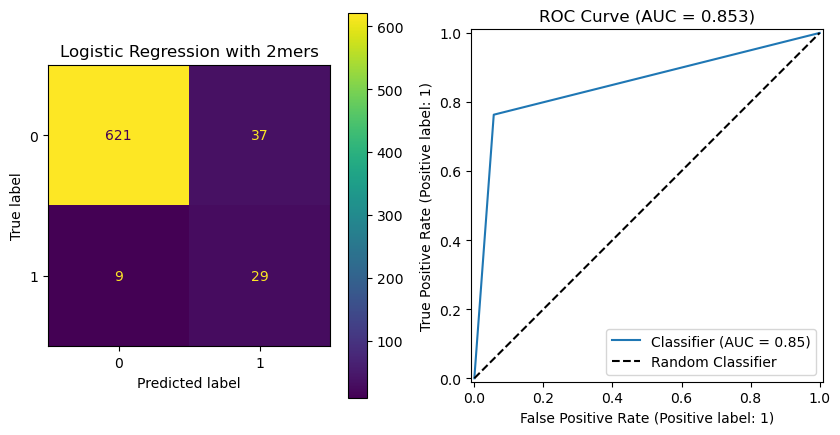

In [219]:
logistic_regression_analysis(X_2, Y, "Logistic Regression with 2mers")

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       658
           1       0.54      0.53      0.53        38

    accuracy                           0.95       696
   macro avg       0.76      0.75      0.75       696
weighted avg       0.95      0.95      0.95       696



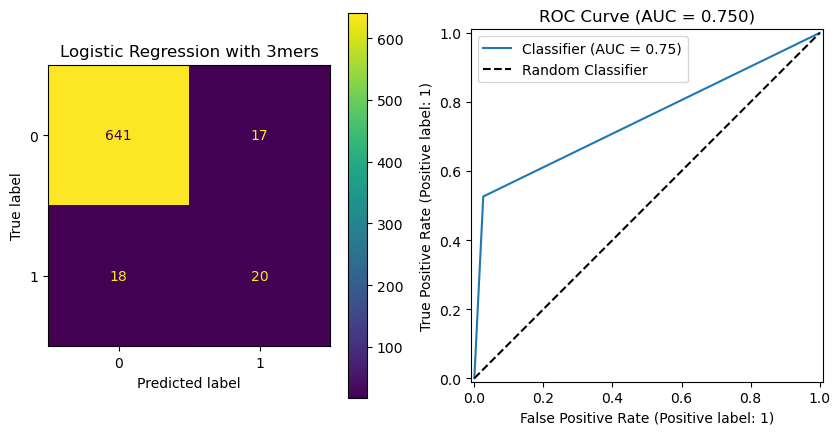

In [220]:
logistic_regression_analysis(X_3, Y, "Logistic Regression with 3mers")

Off the bat it seems to better. Whats also interesting is that as we increased the size of the kmers, the AUC value increased. Lets use grid search again in order to see if we can maximize the precision metric. I will say while playing with this I on accident chose the trimer data and saw I got good results which is why I opted to use this data.

In [ ]:
def grid_search_logistic_regression(X, name, Y):
    print(f"Running Grid Search for Logistic Regression with {X.columns[0].split('mer')[0]}mers...")
    start_time = time.time()
    param_grid = { 'C' : [0.1, 1, 10, 100, 1000],
            'class_weight' : ['balanced', None],
            'solver' : ['lbfgs', 'liblinear', 'sag', 'saga', 'newton-cg']
            }

    grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring = ["precision"],
                        refit="precision", n_jobs=-1,
                        return_train_score=True, cv=10)

    grid_result = grid.fit(X,Y)
    end_time = time.time()
    print(f"Best score for logistic regression with {name}: {grid_result.best_score_}")
    print(f"Best params for logistic regression with {name}: {grid_result.best_params_}")
    print(f"Time taken for logistic regression with {name}: {end_time - start_time:.2f} seconds")    

    return grid_result.best_score_, grid_result.best_params_

In [274]:
def iterate_logistic_regression(X_list, names, Y):
    best_df = None
    best_score = 0
    best_params = []
    best_name = ""
    for X, name in zip(X_list, names):
        score, params = grid_search_logistic_regression(X, name, Y)
        if score > best_score:
            best_df = X
            best_score = score
            best_params = params
            best_name = name
    print(f"Best overall score: {best_score} with {best_name} and params: {best_params["C"]}, {best_params["class_weight"]}, {best_params["solver"]}")
    return best_df, best_score, best_params, best_name

In [300]:
log_df, log_score, log_params, log_name = iterate_logistic_regression([X_2, X_3, X_6], ['2-mer', '3-mer', '6-mer'], Y)

Running Grid Search for Logistic Regression with 2mers...
Best score for logistic regression with 2-mer: 0.5244444444444445
Best params for logistic regression with 2-mer: {'C': 0.1, 'class_weight': None, 'solver': 'liblinear'}
Time taken for logistic regression with 2-mer: 13.40 seconds
Running Grid Search for Logistic Regression with 3mers...
Best score for logistic regression with 3-mer: 0.4241687192118226
Best params for logistic regression with 3-mer: {'C': 10, 'class_weight': None, 'solver': 'liblinear'}
Time taken for logistic regression with 3-mer: 16.27 seconds
Running Grid Search for Logistic Regression with 6mers...
Best score for logistic regression with 6-mer: 0.45285333631885355
Best params for logistic regression with 6-mer: {'C': 1, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Time taken for logistic regression with 6-mer: 318.08 seconds
Best overall score: 0.5244444444444445 with 2-mer and params: 0.1, None, liblinear


c:\Users\jesse\anaconda3\envs\ImmunoglobulinML\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

           0       0.80      0.98      0.88       658
           1       0.64      0.12      0.21       184

    accuracy                           0.79       842
   macro avg       0.72      0.55      0.55       842
weighted avg       0.76      0.79      0.73       842



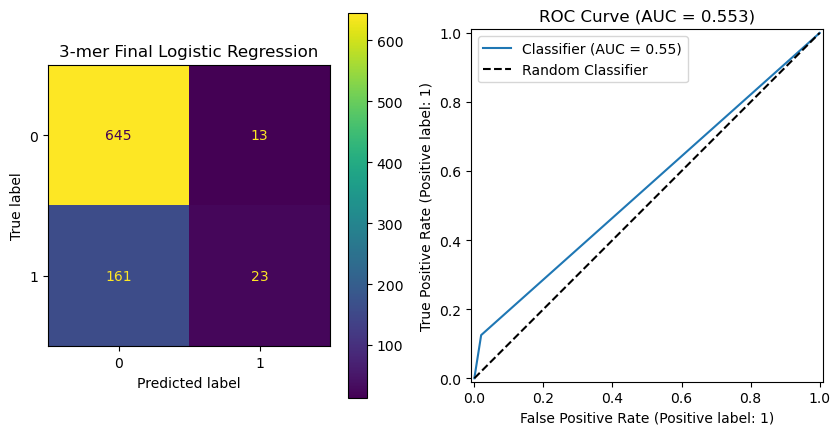

In [301]:
clf_log_final = LogisticRegression(C = log_params['C'], max_iter = 1000, class_weight = log_params['class_weight'], solver = log_params['solver'])

pred_log_final = cross_val_predict(clf_log_final, log_df, Y, cv=10) # Initial Test
print(classification_report(Y, pred_log_final)) # Show classification report

fig, ax = plt.subplots(1, 2, figsize=(10,5))

cfm = confusion_matrix(Y, pred_log_final)
ConfusionMatrixDisplay(confusion_matrix=cfm).plot(ax=ax[0])
ax[0].set_title("3-mer Final Logistic Regression")

# ROC Curve - CODE YOU CAN USE TO SHOW AN ROC CURVE!
roc_auc = roc_auc_score(Y, pred_log_final)
RocCurveDisplay.from_predictions(Y, pred_log_final, ax=ax[1])
ax[1].set_title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.legend()
plt.show()
plt.show()

We were able to get 100% precision using logistic regression! Lets take a look at the results that were incorrectly identified before finishing up.

In [282]:
dt_false_results = pd.concat([pca_plot_df, pd.Series(pred_dt_final, name='Guess')], axis=1)
dt_false_results["Correct"] = np.where(dt_false_results['source'].cat.codes == dt_false_results['Guess'], 'Correct', 'Incorrect')
dt_false_results["Correct"] = dt_false_results["Correct"].astype('category')
dt_false_results.head(3)

,PC1,PC2,PC3,source,Guess,Correct
0,-0.092450,0.775023,-0.400896,cur,0,Correct
1,-7.345647,1.454438,-5.265933,cur,0,Correct
2,0.558326,-0.116753,0.638596,cur,0,Correct


In [283]:
log_false_results = pd.concat([pca_plot_df, pd.Series(pred_log_final, name='Guess')], axis=1)
log_false_results["Correct"] = np.where(log_false_results['source'].cat.codes == log_false_results['Guess'], 'Correct', 'Incorrect')
log_false_results["Correct"] = log_false_results["Correct"].astype('category')
log_false_results.head(3)

,PC1,PC2,PC3,source,Guess,Correct
0,-0.092450,0.775023,-0.400896,cur,0,Correct
1,-7.345647,1.454438,-5.265933,cur,1,Incorrect
2,0.558326,-0.116753,0.638596,cur,0,Correct


Text(0.5, 1.0, 'Logistic Regression')

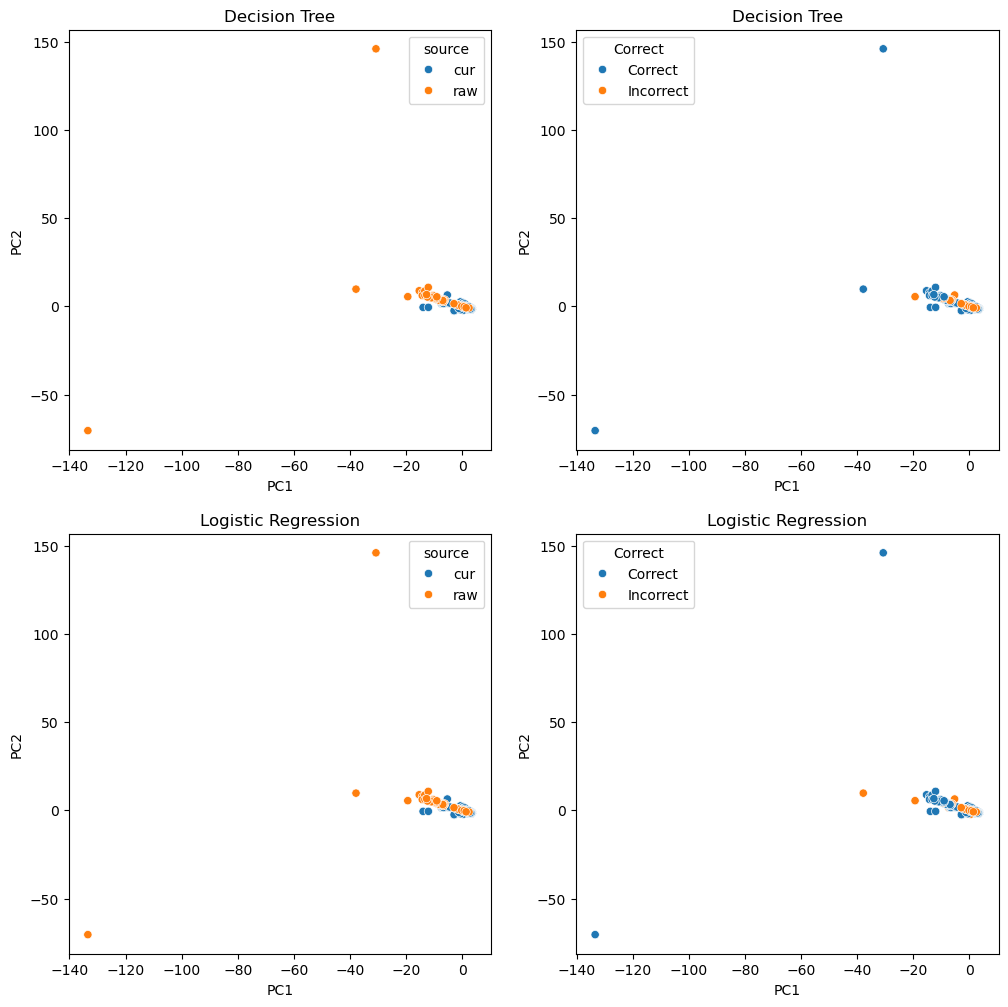

In [287]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12));

sns.scatterplot(data=dt_false_results, x='PC1', y='PC2', hue='source', ax = ax[0, 0]);
ax[0, 0].set_title("Decision Tree")
sns.scatterplot(data=dt_false_results, x='PC1', y='PC2', hue='Correct', ax = ax[0, 1]);
ax[0, 1].set_title("Decision Tree")
sns.scatterplot(data=log_false_results, x='PC1', y='PC2', hue='source', ax = ax[1, 0]);
ax[1, 0].set_title("Logistic Regression")
sns.scatterplot(data=log_false_results, x='PC1', y='PC2', hue='Correct', ax = ax[1, 1]);
ax[1, 1].set_title("Logistic Regression")

Text(0.5, 0, 'PC3')

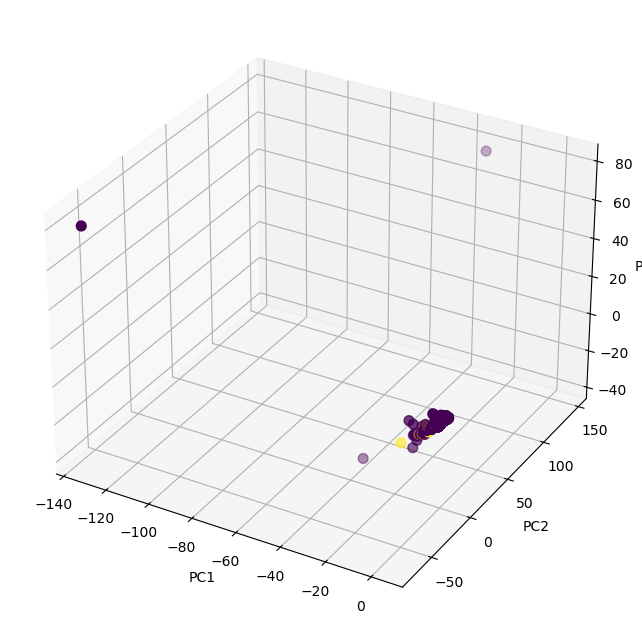

In [289]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(dt_false_results.iloc[:,0], dt_false_results.iloc[:,1], dt_false_results.iloc[:,2], c=dt_false_results['Correct'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

Text(0.5, 0, 'PC3')

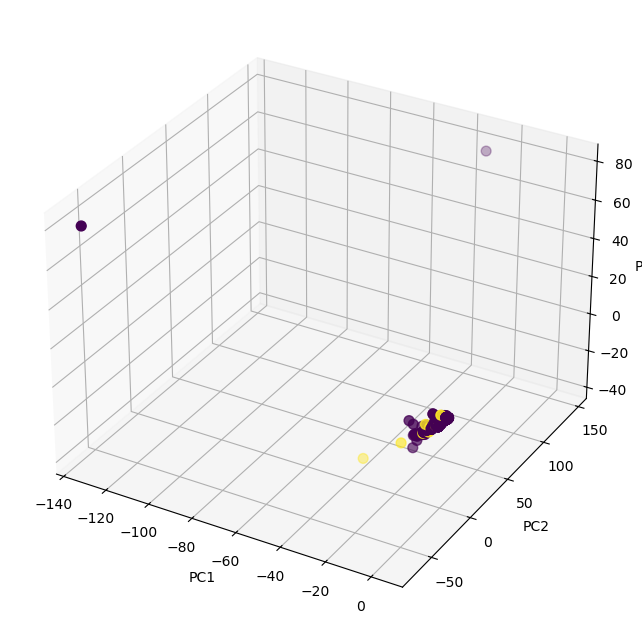

In [288]:
fig = plt.figure(figsize = (8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(log_false_results.iloc[:,0], log_false_results.iloc[:,1], log_false_results.iloc[:,2], c=log_false_results['Correct'].cat.codes, cmap='viridis', s=50)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

I am unsure as to why the data points that were incorrectly identified were incorrectly identified because they are not on what I would imagine to be the border between the two classes.

# Conclusion

Ultimately this project was succesful in being able to differentiate raw digger output from polished curated annotations. We also were able to minimize the number of false negatives to 0 which would prevent the need for a user to review the annotations identified as incorrect. I think using a larger dataset would benefit this study in order to truly see how accurate it could be and to also see if it could have real world use.

# Acknowledgements

I would like to thank Dr Ken Field, Ashley Reers for guidance on the biological side of working on this project in addition to providing me with the data for this project. I would also like to thank Dr Brian King for his help on the technical side of this project.

ChatGPT and Copilot was used on this project for both coding and help understanding differences however everything written in a markdown is my own writing.